## 1.0 Importação das Bibliotecas

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from feature_engine.selection import (
    DropConstantFeatures,
    DropCorrelatedFeatures,
    SmartCorrelatedSelection,
)

## 2.0 Carregamento dos Dados

In [82]:
ch=pd.read_csv('data/train.csv',index_col='id')
print(ch.shape)
ch

(594194, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
id,,,,,,,,,,,,,,,,,,,,
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,No
594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,No
594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,No


### 2.1 Distribuição do Target

Desbalanceamento: ~77.5% No / ~22.5% Yes — estratificação obrigatória.

In [83]:

ch['Churn'].value_counts(normalize=True)

Churn
No     0.774792
Yes    0.225208
Name: proportion, dtype: float64

### 2.2 Divisão Treino/Teste

Dado o desbalanceamento da variável target, é necessário o uso de `stratify`.

In [84]:

x_train,x_test,y_train,y_test=train_test_split(ch.drop('Churn',axis=1),ch['Churn'].map({'No': 0, 'Yes': 1}),test_size=0.2,random_state=42,stratify=ch['Churn'])
x_train.shape,x_test.shape,y_train.shape,y_test.shape


((475355, 19), (118839, 19), (475355,), (118839,))

In [85]:
print(x_train.info())
x_train.head()

<class 'pandas.core.frame.DataFrame'>
Index: 475355 entries, 6165 to 280641
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            475355 non-null  object 
 1   SeniorCitizen     475355 non-null  int64  
 2   Partner           475355 non-null  object 
 3   Dependents        475355 non-null  object 
 4   tenure            475355 non-null  int64  
 5   PhoneService      475355 non-null  object 
 6   MultipleLines     475355 non-null  object 
 7   InternetService   475355 non-null  object 
 8   OnlineSecurity    475355 non-null  object 
 9   OnlineBackup      475355 non-null  object 
 10  DeviceProtection  475355 non-null  object 
 11  TechSupport       475355 non-null  object 
 12  StreamingTV       475355 non-null  object 
 13  StreamingMovies   475355 non-null  object 
 14  Contract          475355 non-null  object 
 15  PaperlessBilling  475355 non-null  object 
 16  PaymentMethod     4753

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
id,,,,,,,,,,,,,,,,,,,
6165,Male,0,Yes,No,60,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,104.90,6273.40
565551,Female,1,No,No,47,Yes,Yes,DSL,No,Yes,No,No,Yes,Yes,One year,No,Electronic check,74.40,3847.75
85537,Female,0,No,Yes,11,Yes,No,DSL,No,No,No,Yes,No,Yes,Month-to-month,No,Bank transfer (automatic),59.45,669.45
137025,Female,0,Yes,Yes,35,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,One year,No,Bank transfer (automatic),62.25,2460.55
436494,Female,0,No,No,56,Yes,No,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.50,5149.45


## 3.0 Análise Descritiva

In [86]:
x_train.describe(include='object').T.sort_values('unique')

,count,unique,top,freq
gender,475355,2,Female,238927
Partner,475355,2,Yes,247799
Dependents,475355,2,No,331445
PhoneService,475355,2,Yes,446290
PaperlessBilling,475355,2,Yes,292581
MultipleLines,475355,3,No,226832
InternetService,475355,3,Fiber optic,218053
OnlineSecurity,475355,3,No,231550
OnlineBackup,475355,3,No,200138
DeviceProtection,475355,3,No,197863


In [87]:
x_train.describe(exclude='object').T.sort_values('mean')

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,475355.0,0.113963,0.317767,0.00,0.00,0.00,0.0,1.00
tenure,475355.0,36.574846,25.052064,1.00,12.00,35.00,62.0,72.00
MonthlyCharges,475355.0,65.892025,31.078944,18.25,29.90,74.15,90.8,118.75
TotalCharges,475355.0,2495.627796,2355.014539,18.80,639.95,1434.65,4264.0,8684.80


In [88]:
cat_vars=x_train.describe(include='object').columns
num_vars=x_train.describe(exclude='object').columns

In [89]:
x_train[num_vars].corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,-0.084576,0.228981,0.042812
tenure,-0.084576,1.000000,0.125093,0.769911
MonthlyCharges,0.228981,0.125093,1.000000,0.634832
TotalCharges,0.042812,0.769911,0.634832,1.000000


In [90]:
cat_vars

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

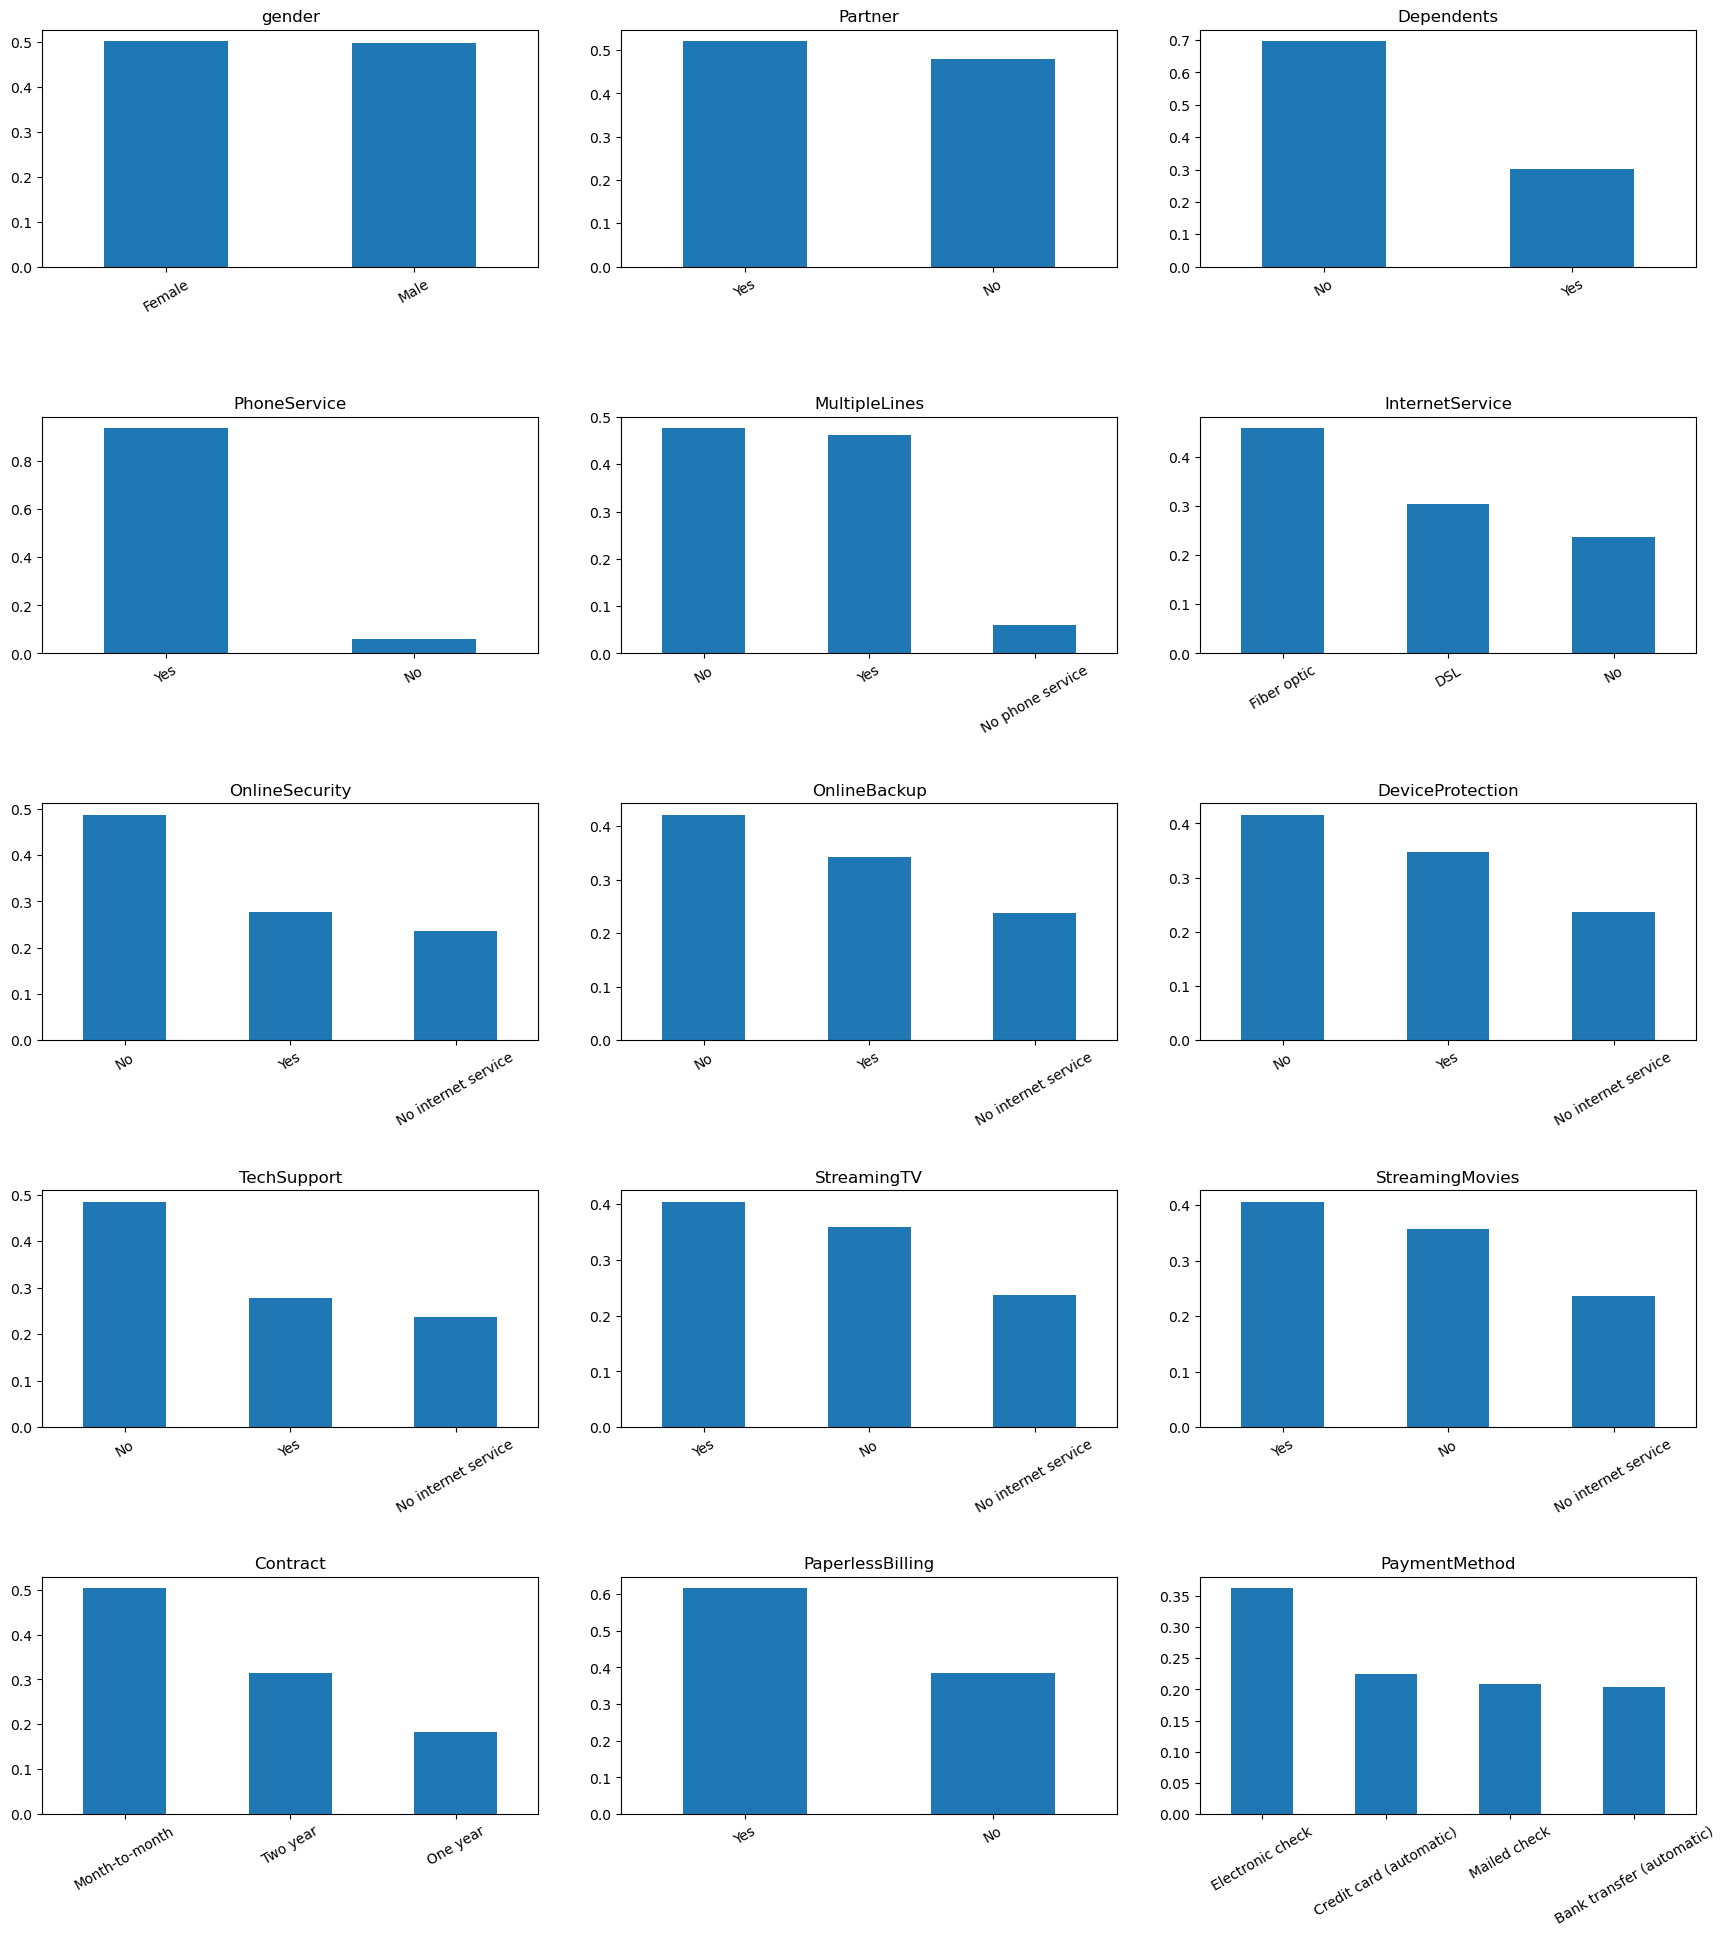

In [91]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(cat_vars):
    x_train[col].value_counts(normalize=True).plot(kind='bar', ax=axes[i], title=col)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_xlabel('')

plt.tight_layout(pad=3.0)
plt.show()

array([[<Axes: title={'center': 'SeniorCitizen'}>,
        <Axes: title={'center': 'tenure'}>],
       [<Axes: title={'center': 'MonthlyCharges'}>,
        <Axes: title={'center': 'TotalCharges'}>]], dtype=object)

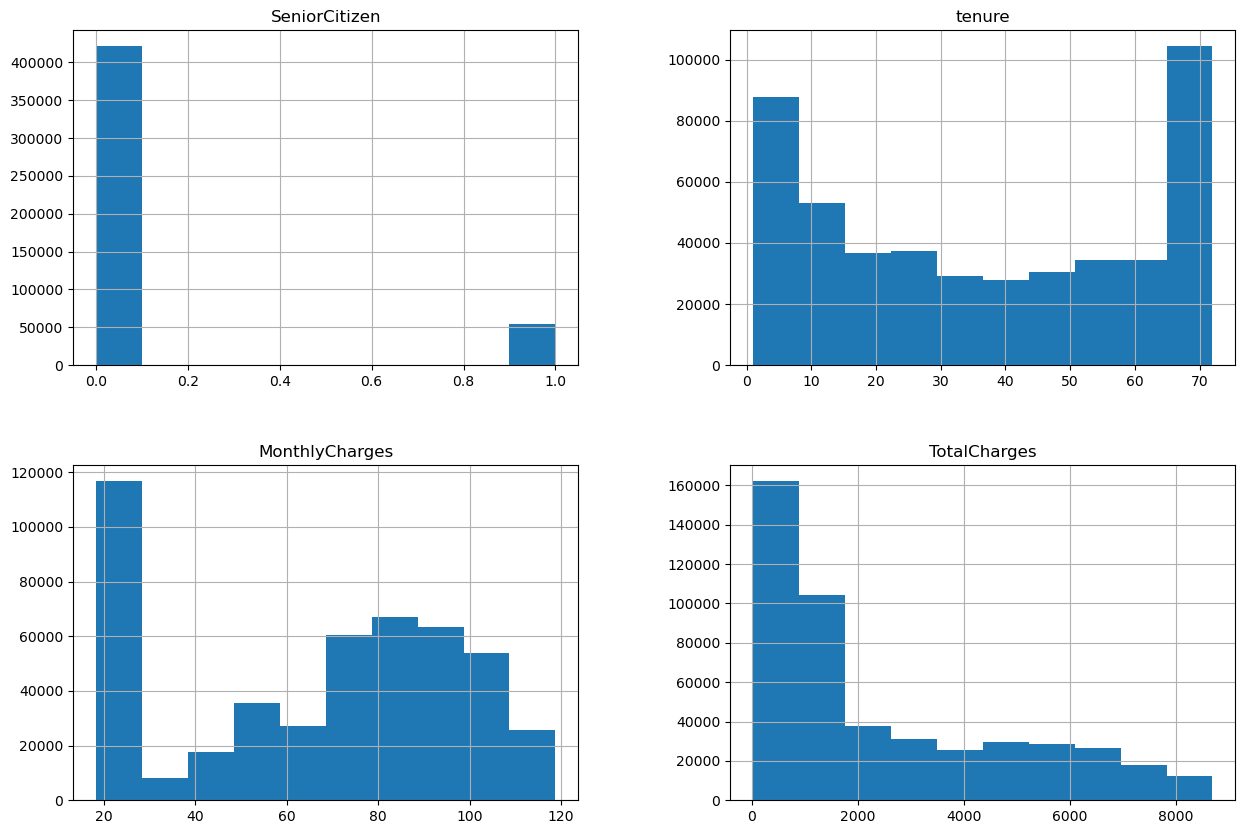

In [92]:
x_train[num_vars].hist(figsize=(15,10))

In [93]:
num_vars = num_vars.drop('SeniorCitizen')
cat_vars = cat_vars.append(pd.Index(['SeniorCitizen']))

## 4.0 Pré-processamento

Aplicamos aqui um baseline de pré-processamento simples: **OneHotEncoder** para variáveis categóricas e **StandardScaler** para variáveis numéricas.

O objetivo desta etapa não é otimizar o preprocessamento, mas sim ter uma base justa para comparar os modelos. A partir dos **top 3 modelos** identificados na Fase 1, avançaremos para testes com diferentes encoders, estratégias de feature engineering e, por fim, fine-tuning com Optuna.

In [94]:
cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_vars),
    ("cat", cat_pipeline, cat_vars)
])

## 5.0 Fase 1 — Baseline: Ranqueamento dos Modelos

Preprocessamento fixo (OneHotEncoder + StandardScaler) aplicado a todos os modelos.
Objetivo: identificar os **top 3** para tuning nas fases seguintes.

In [ ]:
modelos = {
    "LogReg": LogisticRegression(max_iter=1000, random_state=42),
    "RF":     RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGB":    XGBClassifier(eval_metric="logloss", random_state=42, verbosity=0),
    "LGBM":   LGBMClassifier(random_state=42, verbose=-1),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados_fase1 = []

for model_name, modelo in modelos.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", modelo)
    ])

    scores = cross_val_score(pipe, x_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

    resultados_fase1.append({
        "Model":        model_name,
        "ROC-AUC Mean": scores.mean(),
        "ROC-AUC Std":  scores.std(),
    })

    print(f"{model_name:<12}  →  {scores.mean():.5f} ± {scores.std():.4f}")

df_fase1 = (
    pd.DataFrame(resultados_fase1)
    .sort_values("ROC-AUC Mean", ascending=False)
    .reset_index(drop=True)
)

print("\n--- Ranking Final ---")
df_fase1

LogReg        →  0.9078 ± 0.0011
RF            →  0.8923 ± 0.0011
XGB           →  0.9153 ± 0.0009
LGBM          →  0.9150 ± 0.0011
CatBoost      →  0.9158 ± 0.0010

--- Ranking Final ---


,Model,ROC-AUC Mean,ROC-AUC Std
0,CatBoost,0.915789,0.000973
1,XGB,0.915253,0.000934
2,LGBM,0.914980,0.001066
3,LogReg,0.907819,0.001074
4,RF,0.892343,0.001146


## 6.0 Fase 2 — Feature Engineering + Encoders + Feature Selection

Usando os **top 3 modelos** da Fase 1 (CatBoost, XGB, LGBM), testamos todas as combinações de:
- **Feature sets:** original vs. com features criadas manualmente
- **Encoders:** OneHotEncoder vs. BinaryEncoder (sem scaler — árvores são invariantes à escala)
- **Feature selection:** sem seleção, DropConstant+DropCorrelated, SmartCorrelatedSelection

Total: 2 × 2 × 3 × 3 = **36 combinações**

In [ ]:
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

def create_features(df):
    df = df.copy()
    df['charges_per_tenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)
    df['charges_diff']       = df['TotalCharges'] - (df['MonthlyCharges'] * df['tenure'])
    df['is_new_customer']    = (df['tenure'] <= 12).astype(int)
    df['is_monthly']         = (df['Contract'] == 'Month-to-month').astype(int)
    df['n_services']         = (df[service_cols] == 'Yes').sum(axis=1)
    df['senior_no_support']  = ((df['SeniorCitizen'] == 1) & (df['TechSupport'] == 'No')).astype(int)
    return df

new_num_features = ['charges_per_tenure', 'charges_diff', 'is_new_customer',
                    'is_monthly', 'n_services', 'senior_no_support']

x_train_feat = create_features(x_train)

num_vars_feat = num_vars.tolist() + new_num_features
cat_vars_feat = cat_vars.tolist()

print(f"Features originais:   {len(num_vars) + len(cat_vars)}")
print(f"Features engineered:  {len(num_vars_feat) + len(cat_vars_feat)}")
print(f"Novas features:       {new_num_features}")

In [ ]:
from sklearn.base import clone
from category_encoders import BinaryEncoder

encoders_grid = {
    'OneHot': OneHotEncoder(handle_unknown='ignore', sparse_output=False),
    'Binary': BinaryEncoder(),
}

feature_sets = {
    'Original':   (x_train,      num_vars.tolist(),  cat_vars.tolist()),
    'Engineered': (x_train_feat, num_vars_feat,       cat_vars_feat),
}

selections = {
    'NoSelection':    [],
    'DropConst+Corr': [('drop_const', DropConstantFeatures(tol=0.95)),
                       ('drop_corr',  DropCorrelatedFeatures(threshold=0.85))],
    'SmartCorr':      [('smart_corr', SmartCorrelatedSelection(threshold=0.85, selection_method='variance'))],
}

top3 = {
    'XGB':      XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0),
    'LGBM':     LGBMClassifier(random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados_fase2 = []

for feat_name, (X, n_vars, c_vars) in feature_sets.items():
    for enc_name, encoder in encoders_grid.items():
        for sel_name, sel_steps in selections.items():
            for model_name, modelo in top3.items():

                prep = ColumnTransformer(transformers=[
                    ('num', 'passthrough', n_vars),
                    ('cat', clone(encoder), c_vars),
                ], verbose_feature_names_out=False)
                prep.set_output(transform='pandas')

                steps = [('prep', prep)]
                steps += [(n, clone(e)) for n, e in sel_steps]
                steps += [('model', clone(modelo))]

                pipe = Pipeline(steps)
                scores = cross_val_score(pipe, X, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

                resultados_fase2.append({
                    'Features':     feat_name,
                    'Encoder':      enc_name,
                    'Selection':    sel_name,
                    'Model':        model_name,
                    'ROC-AUC Mean': scores.mean(),
                    'ROC-AUC Std':  scores.std(),
                })

                print(f"{feat_name:<12} | {enc_name:<7} | {sel_name:<16} | {model_name:<9}  →  {scores.mean():.4f} ± {scores.std():.4f}")

df_fase2 = (
    pd.DataFrame(resultados_fase2)
    .sort_values('ROC-AUC Mean', ascending=False)
    .reset_index(drop=True)
)

print("\n--- Top 10 Combinações ---")
df_fase2.head(10)

In [ ]:
best_per_model = (
    df_fase2
    .sort_values('ROC-AUC Mean', ascending=False)
    .groupby('Model')
    .first()
    .reset_index()
)

print(best_per_model[['Model', 'Features', 'Encoder', 'Selection', 'ROC-AUC Mean']].to_string(index=False))

## 7.0 Fase 3 — Fine-tuning com Optuna

Tuning dos top 3 modelos usando a melhor configuração encontrada na Fase 2.
Foco nos hiperparâmetros de maior impacto em GBMs.

In [99]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Config vencedora da Fase 2 por modelo
configs = {
    'CatBoost': {'X': x_train,      'n_vars': num_vars.tolist(), 'c_vars': cat_vars.tolist()},
    'XGB':      {'X': x_train,      'n_vars': num_vars.tolist(), 'c_vars': cat_vars.tolist()},
    'LGBM':     {'X': x_train_feat, 'n_vars': num_vars_feat,     'c_vars': cat_vars_feat},
}

def make_prep(n_vars, c_vars):
    prep = ColumnTransformer(transformers=[
        ('num', 'passthrough', n_vars),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), c_vars),
    ], verbose_feature_names_out=False)
    prep.set_output(transform='pandas')
    return prep

def objective_xgb(trial, X, n_vars, c_vars):
    params = {
        'n_estimators':  trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':     trial.suggest_int('max_depth', 3, 8),
        'subsample':     trial.suggest_float('subsample', 0.6, 1.0),
    }
    pipe = Pipeline([('prep', make_prep(n_vars, c_vars)),
                     ('model', XGBClassifier(**params, eval_metric='logloss', random_state=42, verbosity=0))])
    return cross_val_score(pipe, X, y_train, cv=cv, scoring='roc_auc', n_jobs=-1).mean()

def objective_lgbm(trial, X, n_vars, c_vars):
    params = {
        'n_estimators':  trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':     trial.suggest_int('max_depth', 3, 8),
        'subsample':     trial.suggest_float('subsample', 0.6, 1.0),
    }
    pipe = Pipeline([('prep', make_prep(n_vars, c_vars)),
                     ('model', LGBMClassifier(**params, random_state=42, verbose=-1))])
    return cross_val_score(pipe, X, y_train, cv=cv, scoring='roc_auc', n_jobs=-1).mean()

def objective_catboost(trial, X, n_vars, c_vars):
    params = {
        'iterations':    trial.suggest_int('iterations', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth':         trial.suggest_int('depth', 3, 8),
        'subsample':     trial.suggest_float('subsample', 0.6, 1.0),
    }
    pipe = Pipeline([('prep', make_prep(n_vars, c_vars)),
                     ('model', CatBoostClassifier(**params, random_state=42, verbose=0))])
    return cross_val_score(pipe, X, y_train, cv=cv, scoring='roc_auc', n_jobs=-1).mean()

objectives = {
    'XGB':      objective_xgb,
    'LGBM':     objective_lgbm,
    'CatBoost': objective_catboost,
}

N_TRIALS = 10
melhores_params = {}

for model_name, cfg in configs.items():
    print(f"Otimizando {model_name}...")
    study = optuna.create_study(direction='maximize')
    study.optimize(
        lambda trial, m=model_name, c=cfg: objectives[m](trial, c['X'], c['n_vars'], c['c_vars']),
        n_trials=N_TRIALS,
        show_progress_bar=True,
    )
    melhores_params[model_name] = study.best_params
    print(f"  → Melhor AUC: {study.best_value:.4f} | Params: {study.best_params}\n")

Otimizando CatBoost...


  0%|          | 0/10 [00:00<?, ?it/s]

  → Melhor AUC: 0.9161 | Params: {'iterations': 607, 'learning_rate': 0.18222197598571857, 'depth': 4, 'subsample': 0.9873893157745731}

Otimizando XGB...


  0%|          | 0/10 [00:00<?, ?it/s]

  → Melhor AUC: 0.9161 | Params: {'n_estimators': 986, 'learning_rate': 0.08255052666907138, 'max_depth': 4, 'subsample': 0.8212325358525544}

Otimizando LGBM...


  0%|          | 0/10 [00:00<?, ?it/s]

  → Melhor AUC: 0.9159 | Params: {'n_estimators': 954, 'learning_rate': 0.02899801239875284, 'max_depth': 5, 'subsample': 0.7865530372139802}



## 8.0 Submissão

Treina os modelos tunados no dataset completo (`ch`) e gera:
- `submission_individual.csv` — melhor modelo individual
- `submission_ensemble.csv` — média das probabilidades dos 3 modelos

In [100]:
# Dataset completo para treino final
X_full = ch.drop('Churn', axis=1)
y_full = ch['Churn'].map({'No': 0, 'Yes': 1})

X_full_feat = create_features(X_full)

# Test set
test = pd.read_csv('data/test.csv', index_col='id')
test_feat = create_features(test)

# Modelos tunados com melhores params
modelos_tunados = {
    'CatBoost': CatBoostClassifier(**melhores_params['CatBoost'], random_state=42, verbose=0),
    'XGB':      XGBClassifier(**melhores_params['XGB'], eval_metric='logloss', random_state=42, verbosity=0),
    'LGBM':     LGBMClassifier(**melhores_params['LGBM'], random_state=42, verbose=-1),
}

configs_full = {
    'CatBoost': {'X_train': X_full,      'X_test': test,      'n_vars': num_vars.tolist(), 'c_vars': cat_vars.tolist()},
    'XGB':      {'X_train': X_full,      'X_test': test,      'n_vars': num_vars.tolist(), 'c_vars': cat_vars.tolist()},
    'LGBM':     {'X_train': X_full_feat, 'X_test': test_feat, 'n_vars': num_vars_feat,     'c_vars': cat_vars_feat},
}

preds = {}

for model_name, modelo in modelos_tunados.items():
    cfg = configs_full[model_name]
    pipe = Pipeline([
        ('prep',  make_prep(cfg['n_vars'], cfg['c_vars'])),
        ('model', modelo)
    ])
    pipe.fit(cfg['X_train'], y_full)
    preds[model_name] = pipe.predict_proba(cfg['X_test'])[:, 1]
    print(f"{model_name} treinado.")

# --- Submissão individual (melhor modelo = CatBoost) ---
sub_individual = pd.DataFrame({'id': test.index, 'Churn': preds['CatBoost']})
sub_individual.to_csv('data/submission_individual.csv', index=False)

# --- Submissão ensemble (média simples dos 3) ---
pred_ensemble = (preds['CatBoost'] + preds['XGB'] + preds['LGBM']) / 3
sub_ensemble = pd.DataFrame({'id': test.index, 'Churn': pred_ensemble})
sub_ensemble.to_csv('data/submission_ensemble.csv', index=False)

print("\nArquivos gerados:")
print("  data/submission_individual.csv")
print("  data/submission_ensemble.csv")
sub_ensemble.head()

CatBoost treinado.
XGB treinado.


c:\Users\Gabri\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] O sistema não pode encontrar o arquivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Gabri\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Gabri\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Gabri\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^

LGBM treinado.

Arquivos gerados:
  data/submission_individual.csv
  data/submission_ensemble.csv


,id,Churn
0,594194,0.070792
1,594195,0.000575
2,594196,0.107073
3,594197,0.002985
4,594198,0.518046


## 9.0 Conclusões e Possíveis Melhorias

### Resultados

| Fase | Melhor AUC | Modelo |
|---|---|---|
| Baseline (Fase 1) | 0.9158 | CatBoost |
| Feature Eng. + Encoders (Fase 2) | 0.9158 | CatBoost |
| Fine-tuning Optuna (Fase 3) | 0.9161 | CatBoost / XGB |

### Principais Observações

- Os **três GBMs (CatBoost, XGB, LGBM)** tiveram desempenho muito próximo desde o baseline, com diferença menor que 0.002 entre eles.
- As estratégias de **feature engineering e seleção de features** não trouxeram ganho significativo em relação ao preprocessamento simples — indicando que os modelos já extraem bem a informação presente nos dados originais.

### Possíveis Melhorias

1. **Testar novas features** — as features criadas manualmente não agregaram valor. Vale explorar interações mais sofisticadas, como `MonthlyCharges × Contract`, ou features baseadas em clusters de comportamento de cliente.

2. **Aumentar os trials do Optuna** — com apenas 10 trials, o espaço de hiperparâmetros foi pouco explorado. Rodar 100+ trials no Kaggle (com GPU) tem potencial real de ganho.

3. **Stacking (ensemble avançado)** — em vez de média simples, treinar um meta-modelo (ex: Regressão Logística) que aprende a combinar as previsões dos 3 GBMs. Historicamente traz +0.002 a +0.005 de AUC em relação ao voting simples.

4. **Pseudo-labeling** — usar o modelo treinado para gerar predições no test set, adicionar as predições de alta confiança ao treino e retreinar. Técnica comum nos tops de Kaggle em competições com dados sintéticos.

## Criação de outros teste de features tendo como objetivo aumentar o score do desafio